# 🧠 Aula: Validação Cruzada e Otimização de Hiperparâmetros

## 🎯 **Objetivo da Aula**

Nesta aula, vamos aplicar técnicas de **validação cruzada** e **otimização de hiperparâmetros** para melhorar o desempenho de modelos de classificação, especialmente a **Árvore de Decisão**, que apresentou desempenho inferior à Regressão Logística na atividade anterior.

Ao final da aula, você deverá ser capaz de:

- Compreender a diferença entre **hold-out**, **validação cruzada (K-Fold)**.  
- Aplicar **K-Fold Cross Validation** para avaliar a estabilidade de um modelo.  
- Utilizar o **GridSearchCV** e o **RandomizedSearchCV** para ajustar hiperparâmetros.  
- Avaliar a melhora no desempenho do modelo otimizado em relação ao modelo original.  
- Discutir o impacto do **desbalanceamento de classes** nas métricas de desempenho.

---

💡 *Nesta atividade, continuaremos utilizando o dataset **Default of Credit Card Clients**, que contém informações sobre clientes e se eles ficaram inadimplentes ou não.*


## 💳 Default of Credit Card Clients Dataset

### 📍 Origem e contexto

Este dataset foi disponibilizado pelo **UCI Machine Learning Repository** e contém informações reais de **30.000 clientes de cartões de crédito** de um banco em **Taiwan**.  
O objetivo é prever se um cliente **deixará de pagar a próxima fatura** (*default*) com base em características demográficas e financeiras.

- **Fonte:** UCI Machine Learning Repository  
- **Instituição:** Departamento de Estatística — Universidade Nacional de Taiwan  
- **Número de amostras:** 30.000  
- **Tarefa:** Classificação binária  
- **Variável-alvo:** `default.payment.next.month`  
  - `0` → pagamento normal  
  - `1` → default (inadimplente no próximo mês)


### 📊 Estrutura do dataset

O arquivo contém **24 colunas**, descritas abaixo:

| Coluna | Descrição | Tipo |
|---------|------------|------|
| **ID** | Identificador do cliente (não preditivo) | Numérico |
| **LIMIT_BAL** | Limite total de crédito (em dólares taiwaneses) | Numérico |
| **SEX** | Sexo (1 = masculino, 2 = feminino) | Categórico |
| **EDUCATION** | Grau de escolaridade (1 = pós-graduação, 2 = universidade, 3 = ensino médio, 4 = outros) | Categórico |
| **MARRIAGE** | Estado civil (1 = casado, 2 = solteiro, 3 = outros) | Categórico |
| **AGE** | Idade do cliente (anos) | Numérico |
| **PAY_0** | Status do pagamento de setembro (–1 = pago em dia, 1 = atraso de 1 mês, 2 = atraso de 2 meses, etc.) | Numérico (ordinal) |
| **PAY_2** | Status do pagamento de agosto | Numérico |
| **PAY_3** | Status do pagamento de julho | Numérico |
| **PAY_4** | Status do pagamento de junho | Numérico |
| **PAY_5** | Status do pagamento de maio | Numérico |
| **PAY_6** | Status do pagamento de abril | Numérico |
| **BILL_AMT1** | Valor da fatura em setembro | Numérico |
| **BILL_AMT2** | Valor da fatura em agosto | Numérico |
| **BILL_AMT3** | Valor da fatura em julho | Numérico |
| **BILL_AMT4** | Valor da fatura em junho | Numérico |
| **BILL_AMT5** | Valor da fatura em maio | Numérico |
| **BILL_AMT6** | Valor da fatura em abril | Numérico |
| **PAY_AMT1** | Valor pago em setembro | Numérico |
| **PAY_AMT2** | Valor pago em agosto | Numérico |
| **PAY_AMT3** | Valor pago em julho | Numérico |
| **PAY_AMT4** | Valor pago em junho | Numérico |
| **PAY_AMT5** | Valor pago em maio | Numérico |
| **PAY_AMT6** | Valor pago em abril | Numérico |
| **default.payment.next.month** | Variável alvo (0 = não deu default / 1 = deu default) | Binário |

---

### ⚙️ Pré-processamento recomendado

1. **Remover a coluna `ID`** — não traz informação preditiva.  
2. **Converter variáveis categóricas** (`SEX`, `EDUCATION`, `MARRIAGE`) em formato numérico adequado (LabelEncoder ou `astype('category')`).  
3. **Tratar valores anômalos**:  
   - `EDUCATION` pode conter valores 0, 5 ou 6 → recodificar como “outros”.  
   - `MARRIAGE` pode conter valor 0 → recodificar como “outros”.  
4. **Padronizar as variáveis numéricas** (opcional, mas recomendado para Regressão Logística).  

---

💡 **Observação:**  
Esta base é amplamente utilizada em pesquisas e competições de *machine learning*, pois combina dados financeiros reais, ligeiro desbalanceamento de classes e múltiplas variáveis correlacionadas — ideal para comparar modelos lineares e não-lineares em tarefas de classificação.


### Importações de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Carregar e Pré-Processamento

In [3]:
# Carregar o arquivo 'default of credit card clients.xls' (deve estar no mesmo diretório)
df = pd.read_excel('./default_of_credit_card_clients.xls', header=1)

# Renomear a coluna alvo
df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Remover a coluna 'ID'
df.drop('ID', axis=1, inplace=True)

In [4]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

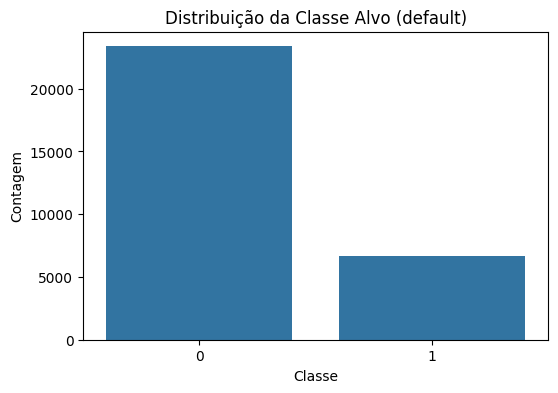

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df)
plt.title('Distribuição da Classe Alvo (default)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

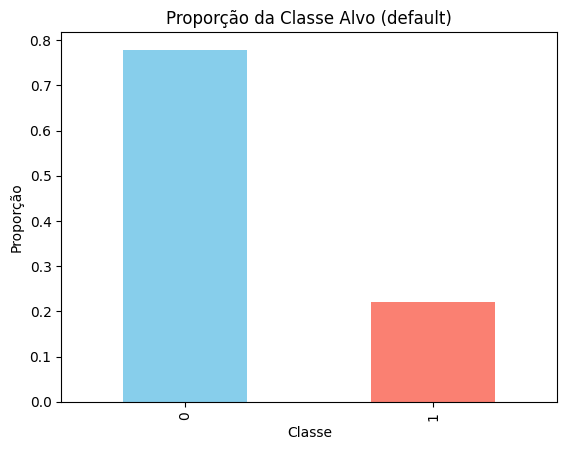

In [7]:
df['default'].value_counts(normalize=True).plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Proporção da Classe Alvo (default)')
plt.xlabel('Classe')
plt.ylabel('Proporção')
plt.show()

In [8]:
df['default'].value_counts(normalize=True)

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

### Tratar valores anômalos:  
   - `EDUCATION` pode conter valores 0, 5 ou 6 → recodificar como “outros (4)”.
   - `MARRIAGE` pode conter valor 0 → recodificar como “outros”.  

In [9]:
df['EDUCATION'].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [10]:
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

In [11]:
df['EDUCATION'].value_counts().sort_index()

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

In [12]:
df['MARRIAGE'].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [13]:
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

In [14]:
df['MARRIAGE'].value_counts().sort_index()

MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

## Divisão Hold-out Final

Antes de aplicar a validação cruzada, vamos separar uma parte dos dados para **teste final**.  Esse conjunto não participará do processo de validação nem do ajuste de hiperparâmetros.

- **Treino (75%)** → usado na validação cruzada e tuning.  
- **Teste (25%)** → usado apenas na etapa final, para avaliar o modelo definitivo.

In [15]:

X = df.drop('default', axis=1)
y = df["default"].copy()

# Split estratificado (ex.: 75% treino, 25% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Checagem rápida dos tamanhos e balanceamento
# Exibir resultados de forma mais clara
print("=== Divisão dos Dados ===")
print(f"Tamanho do treino: {X_train.shape[0]} amostras, {X_train.shape[1]} variáveis")
print(f"Tamanho do teste : {X_test.shape[0]} amostras, {X_test.shape[1]} variáveis\n")

print("=== Proporção de classes no treino ===")
for cls, prop in y_train.value_counts(normalize=True).round(3).items():
    print(f"Classe {cls}: {prop:.1%}")

print("\n=== Proporção de classes no teste ===")
for cls, prop in y_test.value_counts(normalize=True).round(3).items():
    print(f"Classe {cls}: {prop:.1%}")

=== Divisão dos Dados ===
Tamanho do treino: 22500 amostras, 23 variáveis
Tamanho do teste : 7500 amostras, 23 variáveis

=== Proporção de classes no treino ===
Classe 0: 77.9%
Classe 1: 22.1%

=== Proporção de classes no teste ===
Classe 0: 77.9%
Classe 1: 22.1%


## Validação Cruzada (K-Fold) com Pipelines

Avaliaremos dois modelos:
- **Regressão Logística (com StandardScaler)** — sensível à escala dos dados.
- **Árvore de Decisão (sem scaler)** — não depende da escala.

Usaremos **StratifiedKFold (K=5)** para preservar a proporção de classes a cada divisão e métricas adequadas a desbalanceamento:
- `f1_macro` (equilibra importância entre classes),
- `balanced_accuracy` (média do recall por classe),
- `roc_auc` (área sob a curva ROC).


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [17]:
# CV estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
# Pipelines
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipe_dt = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])

In [20]:
# Métricas (todas calculadas via cross_validate)
scoring = {
    'f1_macro': 'f1_macro',
    'bal_acc': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'precision_pos': make_scorer(precision_score, pos_label=1),
    'recall_pos': make_scorer(recall_score, pos_label=1)
}

In [21]:
# Avaliação com cross_validate (retorna média e desvio por métrica)
res_lr = cross_validate(pipe_lr, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
res_dt = cross_validate(pipe_dt, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

In [22]:
def resumo(nome, resultados):
    return pd.Series({
        'F1 (macro)': f"{np.mean(resultados['test_f1_macro']):.4f}",
        'Balanced Acc': f"{np.mean(resultados['test_bal_acc']):.4f}",
        'ROC AUC': f"{np.mean(resultados['test_roc_auc']):.4f}",
        'Precision (classe 1)': f"{np.mean(resultados['test_precision_pos']):.4f}",
        'Recall (classe 1)': f"{np.mean(resultados['test_recall_pos']):.4f}",
    }, name=nome)


In [23]:
tabela = pd.concat([
    resumo('Regressão Logística (com scaler)', res_lr),
    resumo('Árvore de Decisão', res_dt)
], axis=1)

In [24]:
tabela.T

,F1 (macro),Balanced Acc,ROC AUC,Precision (classe 1),Recall (classe 1)
Regressão Logística (com scaler),0.6266,0.6083,0.7254,0.7090,0.2453
Árvore de Decisão,0.6158,0.6190,0.6189,0.3939,0.4225


### Interpretação sugerida para discussão em sala
- **Estabilidade**: observe o desvio-padrão nas métricas entre folds — variação pequena indica modelo estável.
- **Desbalanceamento**: compare `balanced_accuracy` e `f1_macro` com a acurácia simples (se você calcular); acurácia pode mascarar desempenho.
- **Próximo passo**: aplicar **GridSearchCV**/**RandomizedSearchCV** com os **Pipelines** acima para tentar melhorar a **Árvore de Decisão** (e opcionalmente a Regressão Logística).


### Análise e Discussão dos Resultados

Os dois modelos — **Regressão Logística** e **Árvore de Decisão** — foram avaliados com validação cruzada (5-Fold), considerando tanto métricas globais quanto específicas da **classe minoritária (inadimplentes = 1)**.

| Métrica | Regressão Logística | Árvore de Decisão | Interpretação |
|----------|--------------------|------------------|----------------|
| **F1 (macro)** | 0.6266 | 0.6158 | Desempenho geral muito próximo, com leve vantagem para a Regressão Logística. |
| **Balanced Accuracy** | 0.6083 | 0.6190 | Mostra que ambos têm desempenho equilibrado entre classes, mas sem grande diferença. |
| **ROC AUC** | 0.7254 | 0.6189 | A Regressão Logística separa melhor as classes (maior capacidade discriminativa). |
| **Precision (classe 1)** | 0.7090 | 0.3939 | A Regressão Logística é mais “conservadora”: quando prevê inadimplência, acerta com mais frequência. |
| **Recall (classe 1)** | 0.2453 | 0.4225 | A Árvore de Decisão identifica mais inadimplentes, mas com menor precisão. |

---

### 🧠 Interpretação geral

- A **Regressão Logística** apresenta **maior precisão**, mas **baixo recall** para inadimplentes → ou seja, identifica poucos inadimplentes, porém com maior confiança.  
- A **Árvore de Decisão**, por outro lado, é **mais sensível** (maior recall), detectando mais inadimplentes, porém com mais falsos positivos.  
- O **F1-macro** e a **Balanced Accuracy** mostram que, em termos globais, os modelos estão equilibrados — o desafio principal é melhorar o desempenho na **classe 1**.

---

### 💡 Reflexão

- O dataset é **desbalanceado**, e isso impacta fortemente as métricas.  
- Dependendo do objetivo do negócio, pode-se **priorizar recall** (identificar o máximo possível de inadimplentes) ou **precision** (evitar alarmes falsos).  
- A próxima etapa será aplicar **otimização de hiperparâmetros (GridSearchCV e RandomizedSearchCV)** para tentar:
  - aumentar o **recall da Árvore de Decisão**,  
  - equilibrar melhor **precision e recall**,  
  - e verificar se há ganho real no **F1** e **Balanced Accuracy**.

---

📈 *Em resumo:*  
O modelo ainda não é ideal para detectar inadimplentes, mas a Árvore de Decisão tem potencial de melhoria com ajustes de hiperparâmetros — o que exploraremos na sequência.


## ⚙️ Otimização de Hiperparâmetros com GridSearchCV

Agora vamos tentar **melhorar o desempenho da Árvore de Decisão** ajustando seus principais hiperparâmetros.  
O `GridSearchCV` realiza uma **busca exaustiva** entre todas as combinações definidas, usando validação cruzada estratificada (StratifiedKFold).

Os parâmetros mais influentes na árvore são:
- `max_depth`: profundidade máxima da árvore.  
- `min_samples_split`: número mínimo de amostras para dividir um nó.  
- `min_samples_leaf`: número mínimo de amostras em uma folha.  
- `criterion`: função usada para medir a qualidade da divisão.


In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
param_grid = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 3, 5],
    'model__criterion': ['gini', 'entropy'],
    #'model__class_weight': ['balanced', None]
}

grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid,
    scoring='f1_macro',
    refit=True, # Reajusta o modelo com os melhores parâmetros encontrados
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print("🔍 Melhor combinação de parâmetros:")
print(grid_dt.best_params_)
print(f"Melhor F1-macro médio: {grid_dt.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
🔍 Melhor combinação de parâmetros:
{'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Melhor F1-macro médio: 0.6865


In [27]:
# Reaproveita o mesmo esquema de CV e scoring usados antes
res_dt_tuned = cross_validate(grid_dt.best_estimator_, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

In [28]:
tabela_comparativa = pd.concat([
    resumo('Regressão Logística (com scaler)', res_lr),
    resumo('Árvore Original', res_dt),
    resumo('Árvore Otimizada (GridSearchCV)', res_dt_tuned)
], axis=1)

tabela_comparativa.T

,F1 (macro),Balanced Acc,ROC AUC,Precision (classe 1),Recall (classe 1)
Regressão Logística (com scaler),0.6266,0.6083,0.7254,0.7090,0.2453
Árvore Original,0.6158,0.6190,0.6189,0.3939,0.4225
Árvore Otimizada (GridSearchCV),0.6865,0.6610,0.7293,0.6778,0.3723


## Comparação dos Modelos

Após a otimização com **GridSearchCV**, reavaliamos a Árvore de Decisão nas mesmas condições de validação cruzada (5-Fold estratificado), utilizando as mesmas métricas.

| Modelo | F1 (macro) | Balanced Acc | ROC AUC | Precision (classe 1) | Recall (classe 1) |
|--------|-------------|--------------|----------|-----------------------|-------------------|
| **Regressão Logística (com scaler)** | 0.6266 | 0.6083 | 0.7254 | 0.7090 | 0.2453 |
| **Árvore Original** | 0.6158 | 0.6190 | 0.6189 | 0.3939 | 0.4225 |
| **Árvore Otimizada (GridSearchCV)** | **0.6865** | **0.6610** | **0.7293** | **0.6778** | **0.3723** |

---

### 🧠 **Análise dos Resultados**

- 🔸 **F1 (macro):** A Árvore Otimizada obteve o **maior valor geral**, indicando melhor equilíbrio entre precisão e recall das duas classes.  
- 🔸 **Balanced Accuracy:** Houve melhora significativa (de 0.6190 → 0.6610), mostrando que o modelo agora trata melhor ambas as classes.  
- 🔸 **ROC AUC:** A Árvore Otimizada atingiu desempenho próximo ao da Regressão Logística, mostrando boa capacidade de separação entre as classes.  
- 🔸 **Precision (classe 1):** Subiu de 0.3939 → 0.6778, ou seja, o modelo agora acerta com mais confiança quando prevê inadimplência.  
- 🔸 **Recall (classe 1):** Caiu levemente (de 0.4225 → 0.3723), mas ainda mantém desempenho razoável — o modelo ficou mais **preciso** e um pouco menos **sensível**.

---

### 🎯 **Interpretação**

A **otimização via GridSearchCV** foi **efetiva**, especialmente no ganho de *F1-macro* e *Balanced Accuracy*.  
A árvore ficou **mais equilibrada** e **mais confiável nas previsões de inadimplência**, ainda que tenha perdido um pouco de sensibilidade (recall).  

Esses resultados são comuns após o tuning:  
> “O modelo aprende a errar menos, mas às vezes deixa de capturar alguns casos da classe minoritária.”

---

### 💬 **Discussão para a turma**

- O ganho em F1 e Balanced Accuracy indica um modelo mais justo entre as classes.  
- Ainda há espaço para melhorar o **recall da classe 1** — talvez ajustando o limiar de decisão, aplicando **RandomizedSearchCV** com outros hiperparâmetros, ou usando **técnicas de balanceamento** (como `class_weight='balanced'` ou SMOTE).  
- Em aplicações reais, é fundamental decidir o que é mais crítico:  
  - evitar falsos positivos (alta precisão), ou  
  - capturar o máximo de inadimplentes (alto recall).

---

📈 *Conclusão:*  
> O tuning melhorou substancialmente a Árvore de Decisão, aproximando seu desempenho da Regressão Logística e tornando-a uma alternativa competitiva — especialmente considerando seu potencial interpretativo e visual.


## Avaliação no Conjunto de Teste (Hold-out)

Agora comparamos os **três modelos** no **conjunto de teste** usando as mesmas métricas:
- `F1 (macro)`, `Balanced Accuracy`, `ROC AUC`
- `Precision (classe 1)` e `Recall (classe 1)` (foco na classe minoritária)

Isso nos dá a visão de **generalização real** após todo o processo de validação e tuning.

In [29]:
# 1) Garante que os modelos de baseline estejam treinados no conjunto de treino
pipe_lr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


In [30]:
# 2) Melhor modelo da árvore após o GridSearch (já vem re-treinado em X_train se refit=True)
best_dt = grid_dt.best_estimator_

In [31]:
modelos = {
    "Regressão Logística (com scaler)": pipe_lr,
    "Árvore Original": pipe_dt,
    "Árvore Otimizada (GridSearchCV)": best_dt
}

In [32]:
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score


linhas = []
for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    # Para ROC AUC precisamos de probabilidades da classe positiva (1)
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        # fallback raro; para segurança
        auc = np.nan

    resultados = {
        "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
        "Balanced Acc": balanced_accuracy_score(y_test, y_pred),
        "ROC AUC": auc,
        "Precision (classe 1)": precision_score(y_test, y_pred, pos_label=1),
        "Recall (classe 1)": recall_score(y_test, y_pred, pos_label=1),
    }
    # formata com 4 casas para exibição
    linhas.append(pd.Series({k: f"{v:.4f}" if isinstance(v, (float, np.floating)) else v
                             for k, v in resultados.items()}, name=nome))

tabela_teste = pd.DataFrame(linhas)

In [33]:
tabela_teste

,F1 (macro),Balanced Acc,ROC AUC,Precision (classe 1),Recall (classe 1)
Regressão Logística (com scaler),0.6235,0.6060,0.7157,0.7018,0.2411
Árvore Original,0.6029,0.6036,0.6039,0.3794,0.3870
Árvore Otimizada (GridSearchCV),0.6828,0.6584,0.7298,0.6613,0.3707


In [34]:
# 1) Tabelas no mesmo “layout”: modelos nas linhas, métricas nas colunas
cv_tidy    = tabela_comparativa.T.copy()
teste_tidy = tabela_teste.copy()

# 2) Remover espaços estranhos nos nomes de colunas
cv_tidy.columns    = [c.strip() for c in cv_tidy.columns]
teste_tidy.columns = [c.strip() for c in teste_tidy.columns]

# 3) Adicionar sufixos **apenas se ainda não existirem**
if not any(col.endswith(" (CV)") for col in cv_tidy.columns):
    cv_tidy = cv_tidy.add_suffix(" (CV)")

if not any(col.endswith(" (Teste)") for col in teste_tidy.columns):
    teste_tidy = teste_tidy.add_suffix(" (Teste)")

In [35]:
# 4) Juntar lado a lado por modelo
comparacao_final = pd.concat([cv_tidy, teste_tidy], axis=1)

# 5) Intercalar colunas por métrica (CV | Teste)
metricas = [
    "F1 (macro)",
    "Balanced Acc",
    "ROC AUC",
    "Precision (classe 1)",
    "Recall (classe 1)",
]

In [36]:
cols = []
for m in metricas:
    c_cv    = f"{m} (CV)"
    c_test  = f"{m} (Teste)"
    # só adiciona se existirem
    if c_cv in comparacao_final.columns:   cols.append(c_cv)
    if c_test in comparacao_final.columns: cols.append(c_test)

comparacao_pareada = comparacao_final.reindex(columns=cols)
comparacao_pareada

,F1 (macro) (CV),F1 (macro) (Teste),Balanced Acc (CV),Balanced Acc (Teste),ROC AUC (CV),ROC AUC (Teste),Precision (classe 1) (CV),Precision (classe 1) (Teste),Recall (classe 1) (CV),Recall (classe 1) (Teste)
Regressão Logística (com scaler),0.6266,0.6235,0.6083,0.6060,0.7254,0.7157,0.7090,0.7018,0.2453,0.2411
Árvore Original,0.6158,0.6029,0.6190,0.6036,0.6189,0.6039,0.3939,0.3794,0.4225,0.3870
Árvore Otimizada (GridSearchCV),0.6865,0.6828,0.6610,0.6584,0.7293,0.7298,0.6778,0.6613,0.3723,0.3707


In [37]:
def plot_dumbbell(df_pareado: pd.DataFrame, metrica: str):
    """
    Gera um gráfico 'dumbbell' comparando CV vs Teste para cada modelo.
    Azul → resultado da Validação Cruzada
    Laranja → resultado no Teste Final
    """
    col_cv    = f"{metrica} (CV)"
    col_teste = f"{metrica} (Teste)"
    if col_cv not in df_pareado.columns or col_teste not in df_pareado.columns:
        print(f"[Aviso] Colunas não encontradas para '{metrica}'. Pulando…")
        return
    
    # garante que os valores sejam numéricos
    cv_vals    = pd.to_numeric(df_pareado[col_cv], errors="coerce")
    teste_vals = pd.to_numeric(df_pareado[col_teste], errors="coerce")
    modelos    = df_pareado.index.to_list()
    y = np.arange(len(modelos))
    
    plt.figure(figsize=(8, 4))
    
    # desenha as linhas e pontos
    for i in range(len(modelos)):
        plt.plot([cv_vals.iloc[i], teste_vals.iloc[i]], [y[i], y[i]],
                 color="gray", lw=2, zorder=1)
        plt.scatter(cv_vals.iloc[i], y[i], color="royalblue", s=60, label="CV" if i == 0 else "", zorder=2)
        plt.scatter(teste_vals.iloc[i], y[i], color="darkorange", s=60, label="Teste" if i == 0 else "", zorder=3)
    
    plt.yticks(y, modelos)
    plt.xlabel(metrica)
    plt.title(f"CV vs. Teste — {metrica}")
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


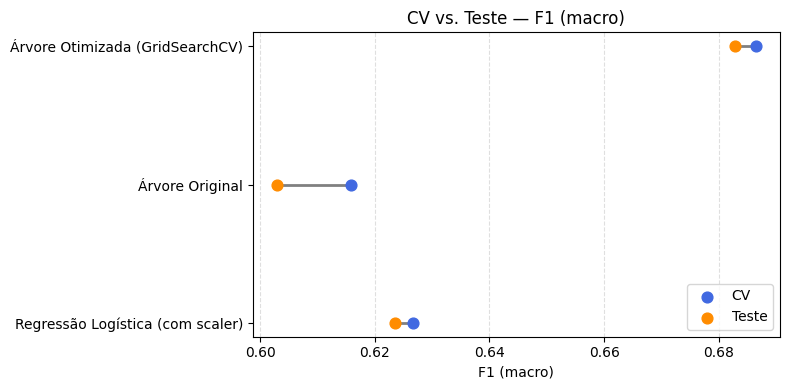

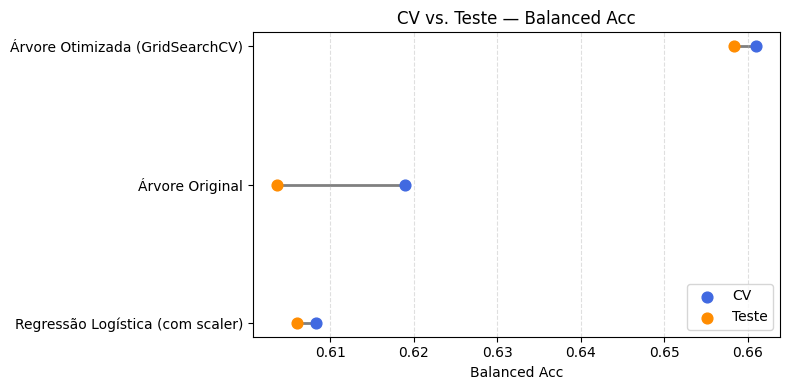

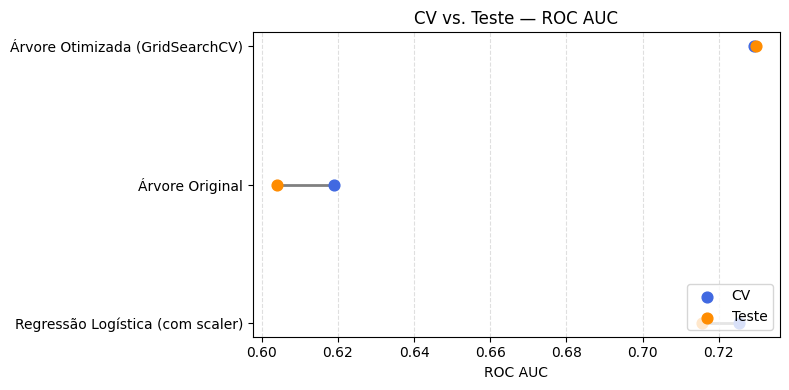

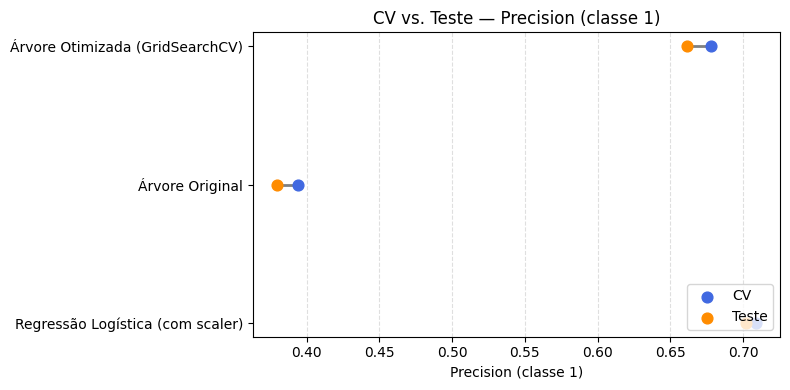

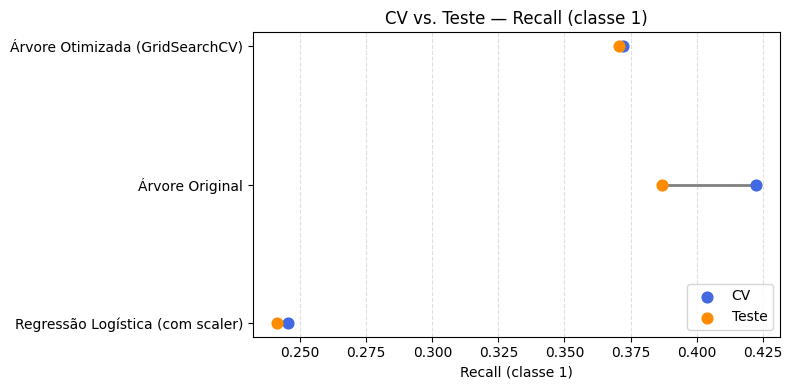

In [38]:
metricas = [
    "F1 (macro)",
    "Balanced Acc",
    "ROC AUC",
    "Precision (classe 1)",
    "Recall (classe 1)",
]

for m in metricas:
    plot_dumbbell(comparacao_pareada, m)

## 🧩 **Atividade 5 – Aplicando SMOTE para Balancear as Classes**

### 🎯 **Objetivo**

Aplicar a técnica **SMOTE (Synthetic Minority Oversampling Technique)** para gerar novas amostras da classe minoritária (inadimplentes) e analisar se o modelo melhora o desempenho na detecção dessa classe.

---

### 🧠 **Passos**

#### 1️⃣ Pesquise brevemente o que é o SMOTE  
- O que ele faz?  
- Por que ele é útil em datasets desbalanceados?

---

#### 2️⃣ Aplique o SMOTE no conjunto de treino
Utilize o código abaixo como base:

```python
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("Tamanho original:", X_train.shape)
print("Tamanho após SMOTE:", X_res.shape)
````

Verifique se as classes ficaram balanceadas:

```python
y_res.value_counts(normalize=True)
```

---

#### 3️⃣ Treine novamente o modelo de Árvore de Decisão

Após aplicar o SMOTE, siga um dos dois caminhos:

* **Opção A:** Treinar novamente o modelo **usando os parâmetros encontrados no GridSearchCV**

  ```python
  best_dt.fit(X_res, y_res)
  ```

  > Essa opção reaproveita os melhores hiperparâmetros já identificados.

* **Opção B:** Executar novamente o `GridSearchCV` sobre os dados balanceados (`X_res`, `y_res`)
  para verificar se os melhores parâmetros mudam após o balanceamento.

---

#### 4️⃣ Aplique o modelo no conjunto de teste

Utilize o conjunto de teste original (`X_test`, `y_test`) para avaliar o desempenho do modelo treinado com os dados balanceados.
Use as mesmas métricas aplicadas anteriormente:

* **F1 (macro)**
* **Balanced Accuracy**
* **ROC AUC**
* **Precision (classe 1)**
* **Recall (classe 1)**

Monte uma **tabela comparando os resultados** com e sem SMOTE, destacando as diferenças nas métricas da classe 1 (inadimplentes).

---

#### 5️⃣ Analise os resultados

* O **recall da classe 1** aumentou após o uso do SMOTE?
* Houve perda de precisão?
* O modelo ficou mais equilibrado entre as classes?

> Lembre-se: o SMOTE deve ser aplicado **somente no conjunto de treino** — nunca no conjunto de teste.

---

### 🧾 **Entrega no Moodle**

📤 **Atividade 5 – Aplicando SMOTE para Balancear as Classes**

Envie no **Moodle da disciplina** o notebook completo (`.ipynb`) contendo:

1. A aplicação do SMOTE;
2. O re-treinamento da Árvore de Decisão (com parâmetros do GridSearchCV ou nova busca);
3. A avaliação no conjunto de teste;
4. E uma breve análise (3–5 linhas) sobre os resultados obtidos.

---

💡 *Dica:* compare diretamente as métricas com e sem SMOTE no conjunto de teste.
Observe se o modelo se tornou mais sensível à classe minoritária (**recall ↑**) ou se perdeu precisão (**precision ↓**).

```
```


## Resolução

#### 1️⃣ Pesquise brevemente o que é o SMOTE

O SMOTE é uma técnica de oversampling que cria novas amostras sintéticas da classe minoritária, combinando observações próximas entre si.

Ele é usado para reduzir o desbalanceamento entre classes e ajudar o modelo a reconhecer melhor padrões da classe menos representada, como os clientes inadimplentes neste caso.

#### 2️⃣ Aplique o SMOTE no conjunto de treino

In [3]:
import sys, subprocess, shlex
print("PY:", sys.executable)
subprocess.run([sys.executable, "-m", "pip", "show", "imbalanced-learn"])

PY: c:\Users\Everton\Documents\IFSP\CMPINAM\1-Aulas\CMPINAM-08-Validacao-Cruzada-e-Otimizacao-de- Hiperparametros\myenv\Scripts\python.exe


CompletedProcess(args=['c:\\Users\\Everton\\Documents\\IFSP\\CMPINAM\\1-Aulas\\CMPINAM-08-Validacao-Cruzada-e-Otimizacao-de- Hiperparametros\\myenv\\Scripts\\python.exe', '-m', 'pip', 'show', 'imbalanced-learn'], returncode=1)

In [4]:
import sys
print(sys.executable)  # só para conferir
!{sys.executable} -m pip install -U pip setuptools wheel
!{sys.executable} -m pip install -U scikit-learn imbalanced-learn

c:\Users\Everton\Documents\IFSP\CMPINAM\1-Aulas\CMPINAM-08-Validacao-Cruzada-e-Otimizacao-de- Hiperparametros\myenv\Scripts\python.exe


'c:\Users\Everton\Documents\IFSP\CMPINAM\1-Aulas\CMPINAM-08-Validacao-Cruzada-e-Otimizacao-de-' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.
'c:\Users\Everton\Documents\IFSP\CMPINAM\1-Aulas\CMPINAM-08-Validacao-Cruzada-e-Otimizacao-de-' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [2]:
from imblearn.over_sampling import SMOTE

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X_train, y_train)

print("Tamanho original:", X_train.shape)
print("Tamanho após SMOTE:", X_smote.shape)